In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
import joblib
import random

# Seed fix pentru reproductibilitate (aceleași rezultate la fiecare rulare)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"PyTorch: {torch.__version__}, Pandas: {pd.__version__}")

PyTorch: 2.10.0, Pandas: 3.0.2


In [2]:
# Coloanele de care avem nevoie din Pink Sheet (iFERTILIZERS scos - nu exista in fisier)
features = ['UREA_EE_BULK', 'NGAS_US', 'NGAS_EUR', 'CRUDE_PETRO',
            'MAIZE', 'WHEAT_US_SRW']

# Fisierul World Bank foloseste nume descriptive in antet (randul 4), nu coduri scurte.
# Mapam numele descriptive la codurile folosite in restul proiectului.
rename_map = {
    'Crude oil, average': 'CRUDE_PETRO',
    'Natural gas, US': 'NGAS_US',
    'Natural gas, Europe': 'NGAS_EUR',
    'Maize': 'MAIZE',
    'Wheat, US SRW': 'WHEAT_US_SRW',
    'Urea': 'UREA_EE_BULK',
}

# Antetul real (numele descriptive) e pe randul 4; randul 5 contine unitatile
df_pink = pd.read_excel('data/CMO-Historical-Data-Monthly.xlsx',
                        sheet_name='Monthly Prices', skiprows=4)

# Prima coloana e data; curatam spatiile si aplicam maparea la coduri
df_pink = df_pink.rename(columns={df_pink.columns[0]: 'Date'})
df_pink.columns = [str(c).strip() for c in df_pink.columns]
df_pink = df_pink.rename(columns=rename_map)

# Aruncam randul cu unitatile ($/bbl, $/mt, ...) si pastram doar lunile valide 'YYYYMmm'
df_pink = df_pink[df_pink['Date'].astype(str).str.match(r'^\d{4}M\d{2}$')].copy()

# Convertim data din format '1960M01' in datetime standard
df_pink['Date'] = pd.to_datetime(df_pink['Date'], format='%YM%m')

# Pastram doar Date + cele 6 features, convertim la numeric
df_pink = df_pink[['Date'] + features].copy()
for col in features:
    df_pink[col] = pd.to_numeric(df_pink[col], errors='coerce')

print(f"Shape: {df_pink.shape}")
print(f"Interval: {df_pink['Date'].min()} -> {df_pink['Date'].max()}")
print(f"\nUltimele randuri:")
print(df_pink.tail())

Shape: (797, 7)
Interval: 1960-01-01 00:00:00 -> 2026-05-01 00:00:00

Ultimele randuri:
          Date  UREA_EE_BULK  NGAS_US  NGAS_EUR  CRUDE_PETRO   MAIZE  \
793 2026-01-01        415.40     7.58     11.76        63.65  204.49   
794 2026-02-01        472.00     3.61     11.24        68.01  209.59   
795 2026-03-01        725.63     3.06     17.91        95.58  212.69   
796 2026-04-01        856.88     2.77     15.41       103.91  214.00   
797 2026-05-01        770.50     2.93     16.17       100.43  216.17   

     WHEAT_US_SRW  
793        217.65  
794        232.35  
795        247.40  
796        246.48  
797        259.54  


In [3]:
# Incarcam cursul valutar USD/EUR
df_fx = pd.read_csv('data/EXUSEU.csv')

# Verificam cum se numesc coloanele si ce format are data
print("Coloane EXUSEU:", list(df_fx.columns))
print(df_fx.head(3))

Coloane EXUSEU: ['observation_date', 'EXUSEU']
  observation_date  EXUSEU
0       1999-01-01  1.1591
1       1999-02-01  1.1203
2       1999-03-01  1.0886


In [4]:
# Convertim data EXUSEU la datetime si o redenumim ca sa se potriveasca cu df_pink
# (idempotent: functioneaza chiar daca celula este rulata de mai multe ori)
if df_fx.index.name == 'Date':
    df_fx = df_fx.reset_index()
if 'observation_date' in df_fx.columns:
    df_fx = df_fx.rename(columns={'observation_date': 'Date'})
df_fx['Date'] = pd.to_datetime(df_fx['Date'])

# Unim cele doua seturi pe coloana Date (inner join = pastram doar lunile prezente in AMBELE)
df = pd.merge(df_pink, df_fx, on='Date', how='inner')

# Sortam cronologic si punem Date ca index
df = df.sort_values('Date').set_index('Date')

print(f"Shape dupa merge: {df.shape}")
print(f"Interval: {df.index.min()} -> {df.index.max()}")
print(f"\nValori lipsa per coloana:")
print(df.isna().sum())
print(f"\nPrimele randuri:")
print(df.head())

Shape dupa merge: (328, 7)
Interval: 1999-01-01 00:00:00 -> 2026-04-01 00:00:00

Valori lipsa per coloana:
UREA_EE_BULK    0
NGAS_US         0
NGAS_EUR        0
CRUDE_PETRO     0
MAIZE           0
WHEAT_US_SRW    7
EXUSEU          0
dtype: int64

Primele randuri:
            UREA_EE_BULK  NGAS_US  NGAS_EUR  CRUDE_PETRO  MAIZE  WHEAT_US_SRW  \
Date                                                                            
1999-01-01          64.5     1.86      2.02        11.44  97.44        103.18   
1999-02-01          64.0     1.77      2.01        10.75  94.19         94.96   
1999-03-01          75.5     1.79      1.95        13.17  96.18        100.24   
1999-04-01          64.5     2.15      1.87        15.87  94.13         99.65   
1999-05-01          64.9     2.25      1.89        16.06  92.49         96.59   

            EXUSEU  
Date                
1999-01-01  1.1591  
1999-02-01  1.1203  
1999-03-01  1.0886  
1999-04-01  1.0701  
1999-05-01  1.0630  


In [5]:
# Forward-fill pentru golurile din WHEAT_US_SRW (foloseste ultima valoare cunoscuta)
df = df.ffill()

# Verificam ca nu mai raman goluri
print("Valori lipsa dupa forward-fill:")
print(df.isna().sum())
print(f"\nShape final: {df.shape}")

Valori lipsa dupa forward-fill:
UREA_EE_BULK    0
NGAS_US         0
NGAS_EUR        0
CRUDE_PETRO     0
MAIZE           0
WHEAT_US_SRW    0
EXUSEU          0
dtype: int64

Shape final: (328, 7)


In [6]:
# Pastram preturile brute separat (ne trebuie mai tarziu la reconstructie)
df_prices = df.copy()

# Calculam log-returns pentru TOATE coloanele: ln(P_t / P_{t-1})
df_logret = np.log(df / df.shift(1))

# Prima linie devine NaN (nu are luna anterioara) - o eliminam
df_logret = df_logret.dropna()

print(f"Shape dupa log-returns: {df_logret.shape}")
print(f"\nStatistici (observa ca valorile sunt mici, in jurul lui 0):")
print(df_logret.describe().round(4))
print(f"\nPrimele randuri:")
print(df_logret.head().round(4))

Shape dupa log-returns: (327, 7)

Statistici (observa ca valorile sunt mici, in jurul lui 0):
       UREA_EE_BULK   NGAS_US  NGAS_EUR  CRUDE_PETRO     MAIZE  WHEAT_US_SRW  \
count      327.0000  327.0000  327.0000     327.0000  327.0000      327.0000   
mean         0.0079    0.0012    0.0062       0.0067    0.0024        0.0027   
std          0.1187    0.1600    0.1158       0.0956    0.0601        0.0681   
min         -0.6931   -0.7418   -0.5799      -0.5049   -0.2449       -0.2603   
25%         -0.0528   -0.0827   -0.0298      -0.0428   -0.0292       -0.0339   
50%          0.0062   -0.0016    0.0052       0.0194    0.0016       -0.0016   
75%          0.0651    0.0839    0.0457       0.0641    0.0365        0.0384   
max          0.7159    0.6413    0.4659       0.3674    0.2199        0.2748   

         EXUSEU  
count  327.0000  
mean     0.0000  
std      0.0217  
min     -0.0780  
25%     -0.0142  
50%      0.0002  
75%      0.0126  
max      0.0619  

Primele randuri:
     

In [7]:
from sklearn.model_selection import train_test_split

LOOK_BACK = 12
TARGET_COL = 0  # UREA_EE_BULK este prima coloana

# Impartim cronologic: 80% train, 20% test (NU amestecam - e serie temporala!)
n = len(df_logret)
train_size = int(n * 0.8)

data_train = df_logret.iloc[:train_size].values
data_test = df_logret.iloc[train_size:].values

print(f"Train: {data_train.shape[0]} luni, Test: {data_test.shape[0]} luni")

# Scalam DOAR pe train, apoi aplicam pe test (ca sa evitam scurgerea de informatie din viitor)
scaler = MinMaxScaler(feature_range=(0, 1))
data_train_scaled = scaler.fit_transform(data_train)
data_test_scaled = scaler.transform(data_test)

# Functie care construieste ferestrele glisante
def create_windows(data, look_back, target_col):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])           # 12 luni, toate cele 7 features
        y.append(data[i+look_back, target_col])  # luna urmatoare, doar ureea
    return np.array(X), np.array(y)

X_train, y_train = create_windows(data_train_scaled, LOOK_BACK, TARGET_COL)
X_test, y_test = create_windows(data_test_scaled, LOOK_BACK, TARGET_COL)

print(f"X_train: {X_train.shape}  (ferestre, luni_per_fereastra, features)")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

Train: 261 luni, Test: 66 luni
X_train: (249, 12, 7)  (ferestre, luni_per_fereastra, features)
y_train: (249,)
X_test:  (54, 12, 7)
y_test:  (54,)


In [8]:
# Numarul de features (7: uree + gaz US/EU + petrol + porumb + grau + curs)
N_FEATURES = X_train.shape[2]

class UreaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)  # din memorie -> 1 predictie

    def forward(self, x):
        out, _ = self.lstm(x)          # trece seria prin LSTM
        out = out[:, -1, :]            # luam doar ultimul pas (luna cea mai recenta)
        return self.fc(out)            # -> predictia

class UreaBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)  # *2 pentru cele 2 directii

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

# Verificam ca se instantiaza corect
lstm_model = UreaLSTM(N_FEATURES)
bilstm_model = UreaBiLSTM(N_FEATURES)
print(lstm_model)
print(bilstm_model)

UreaLSTM(
  (lstm): LSTM(7, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
UreaBiLSTM(
  (lstm): LSTM(7, 32, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [9]:
import copy

def train_model(model, X_train, y_train, X_val, y_val, epochs=600, lr=0.0005, patience=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Convertim datele in tensori PyTorch
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    Xva = torch.tensor(X_val, dtype=torch.float32)
    yva = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    best_val_loss = float('inf')
    best_weights = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # --- ANTRENARE ---
        model.train()
        optimizer.zero_grad()
        pred = model(Xtr)
        loss = criterion(pred, ytr)
        loss.backward()          # PyTorch calculeaza automat ajustarile
        optimizer.step()         # aplicam ajustarile

        # --- VALIDARE (verificam pe date nevazute) ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xva), yva).item()

        # --- EARLY STOPPING ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping la epoca {epoch}")
                break

    model.load_state_dict(best_weights)  # restauram cel mai bun model
    return model

print("Functia de antrenare e definita.")

Functia de antrenare e definita.


In [10]:
# Separam ultimele 10% din TRAIN pentru validare (cronologic, nu aleatoriu)
val_size = int(len(X_train) * 0.1)

X_tr = X_train[:-val_size]
y_tr = y_train[:-val_size]
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

print(f"Antrenare efectiva: {X_tr.shape[0]} ferestre")
print(f"Validare: {X_val.shape[0]} ferestre")
print(f"Test: {X_test.shape[0]} ferestre\n")

# Antrenam LSTM
print("=== Antrenare LSTM ===")
torch.manual_seed(42)  # reproductibilitate
lstm_model = UreaLSTM(N_FEATURES)
lstm_model = train_model(lstm_model, X_tr, y_tr, X_val, y_val)

# Antrenam BiLSTM
print("\n=== Antrenare BiLSTM ===")
torch.manual_seed(42)
bilstm_model = UreaBiLSTM(N_FEATURES)
bilstm_model = train_model(bilstm_model, X_tr, y_tr, X_val, y_val)

print("\nAmbele modele antrenate.")

Antrenare efectiva: 225 ferestre
Validare: 24 ferestre
Test: 54 ferestre

=== Antrenare LSTM ===
  Early stopping la epoca 86

=== Antrenare BiLSTM ===
  Early stopping la epoca 59

Ambele modele antrenate.


In [11]:
def evaluate_model(model, X_test, y_test, scaler, df_prices, train_size, look_back):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()

    # Inversam scalarea DOAR pentru coloana ureei (target)
    # Reconstruim un array fals cu 7 coloane ca sa aplicam inverse_transform
    n_feat = scaler.n_features_in_
    dummy_pred = np.zeros((len(pred_scaled), n_feat))
    dummy_pred[:, 0] = pred_scaled
    pred_logret = scaler.inverse_transform(dummy_pred)[:, 0]

    dummy_true = np.zeros((len(y_test), n_feat))
    dummy_true[:, 0] = y_test
    true_logret = scaler.inverse_transform(dummy_true)[:, 0]

    # Preturile reale corespunzatoare perioadei de test
    # Test incepe la: train_size + look_back (in df_logret), +1 pentru shift-ul log-return
    test_start_idx = train_size + look_back + 1
    prices = df_prices['UREA_EE_BULK'].values
    price_prev = prices[test_start_idx - 1 : test_start_idx - 1 + len(pred_logret)]

    # Reconstruim preturile: pret_t = pret_{t-1} * exp(log_return)
    pred_price = price_prev * np.exp(pred_logret)
    true_price = prices[test_start_idx : test_start_idx + len(pred_logret)]

    return pred_price, true_price

# Metrici
def compute_metrics(true_price, pred_price):
    mae = np.mean(np.abs(true_price - pred_price))
    rmse = np.sqrt(np.mean((true_price - pred_price)**2))
    mape = np.mean(np.abs((true_price - pred_price) / true_price)) * 100
    # Directional accuracy
    true_dir = np.sign(np.diff(true_price))
    pred_dir = np.sign(np.diff(pred_price))
    dir_acc = np.mean(true_dir == pred_dir) * 100
    return mae, rmse, mape, dir_acc

# Evaluam ambele modele
lstm_pred, true_price = evaluate_model(lstm_model, X_test, y_test, scaler, df_prices, train_size, LOOK_BACK)
bilstm_pred, _ = evaluate_model(bilstm_model, X_test, y_test, scaler, df_prices, train_size, LOOK_BACK)

# Naive baseline: pretul de luna trecuta = predictia
naive_pred = true_price[:-1]
naive_true = true_price[1:]

print("Rezultate pe setul de test:\n")
for name, pred, true in [("LSTM", lstm_pred, true_price),
                          ("BiLSTM", bilstm_pred, true_price),
                          ("Naive", naive_pred, naive_true)]:
    mae, rmse, mape, da = compute_metrics(true, pred)
    print(f"{name:8} MAE={mae:7.2f}  RMSE={rmse:7.2f}  MAPE={mape:6.2f}%  DirAcc={da:5.2f}%")

Rezultate pe setul de test:

LSTM     MAE=  47.55  RMSE=  69.95  MAPE=  9.01%  DirAcc=58.49%
BiLSTM   MAE=  46.60  RMSE=  69.21  MAPE=  8.86%  DirAcc=58.49%
Naive    MAE=  46.42  RMSE=  67.30  MAPE=  9.17%  DirAcc=53.85%


In [12]:
# === EXTINDEM FEATURES ===
features_ext = ['UREA_EE_BULK', 'NGAS_US', 'NGAS_EUR', 'NGAS_JP', 'CRUDE_PETRO',
                'MAIZE', 'WHEAT_US_SRW', 'DAP', 'POTASH', 'EXUSEU']

# Reconstruim df cu noile coloane (din Pink Sheet + EXUSEU)
# Fisierul World Bank foloseste nume descriptive in antet (randul 4), nu coduri scurte
rename_map_ext = {
    'Crude oil, average': 'CRUDE_PETRO',
    'Natural gas, US': 'NGAS_US',
    'Natural gas, Europe': 'NGAS_EUR',
    'Liquefied natural gas, Japan': 'NGAS_JP',
    'Maize': 'MAIZE',
    'Wheat, US SRW': 'WHEAT_US_SRW',
    'Urea': 'UREA_EE_BULK',
    'DAP': 'DAP',
    'Potassium chloride **': 'POTASH',
}
df_pink_ext = pd.read_excel('data/CMO-Historical-Data-Monthly.xlsx',
                            sheet_name='Monthly Prices', skiprows=4)
df_pink_ext = df_pink_ext.rename(columns={df_pink_ext.columns[0]: 'Date'})
df_pink_ext.columns = [str(c).strip() for c in df_pink_ext.columns]
df_pink_ext = df_pink_ext.rename(columns=rename_map_ext)
# Aruncam randul cu unitatile si pastram doar lunile valide 'YYYYMmm'
df_pink_ext = df_pink_ext[df_pink_ext['Date'].astype(str).str.match(r'^\d{4}M\d{2}$')].copy()
df_pink_ext['Date'] = pd.to_datetime(df_pink_ext['Date'], format='%YM%m')

pink_cols = [c for c in features_ext if c != 'EXUSEU']
for col in pink_cols:
    df_pink_ext[col] = pd.to_numeric(df_pink_ext[col], errors='coerce')
df_pink_ext = df_pink_ext[['Date'] + pink_cols]

df_ext = pd.merge(df_pink_ext, df_fx, on='Date', how='inner')
df_ext = df_ext.sort_values('Date').set_index('Date').ffill()
df_ext = df_ext[features_ext]  # ordine coloane, uree prima

print(f"Features: {len(features_ext)}, Shape: {df_ext.shape}\n")

df_prices_ext = df_ext.copy()
df_logret_ext = np.log(df_ext / df_ext.shift(1)).dropna()

# === FUNCTIE care ruleaza un experiment complet pentru un look_back dat ===
def run_experiment(look_back, df_logret, df_prices, n_features):
    n = len(df_logret)
    train_size = int(n * 0.8)
    data_train = df_logret.iloc[:train_size].values
    data_test = df_logret.iloc[train_size:].values

    scaler = MinMaxScaler(feature_range=(0, 1))
    data_train_s = scaler.fit_transform(data_train)
    data_test_s = scaler.transform(data_test)

    Xtr, ytr = create_windows(data_train_s, look_back, 0)
    Xte, yte = create_windows(data_test_s, look_back, 0)

    val_size = int(len(Xtr) * 0.1)
    X_t, y_t = Xtr[:-val_size], ytr[:-val_size]
    X_v, y_v = Xtr[-val_size:], ytr[-val_size:]

    results = {}
    for name, ModelClass in [("LSTM", UreaLSTM), ("BiLSTM", UreaBiLSTM)]:
        torch.manual_seed(42)
        model = ModelClass(n_features)
        model = train_model(model, X_t, y_t, X_v, y_v)
        pred, true = evaluate_model(model, Xte, yte, scaler, df_prices, train_size, look_back)
        mae, rmse, mape, da = compute_metrics(true, pred)
        results[name] = (mape, da)
    return results

# === RULAM PENTRU 6, 12, 24 ===
N_FEAT_EXT = len(features_ext)
print("Rulam experimente (poate dura 1-2 min)...\n")
print(f"{'Window':>7} {'Model':>7} {'MAPE':>7} {'DirAcc':>8}")
print("-" * 32)
for lb in [6, 12, 24]:
    res = run_experiment(lb, df_logret_ext, df_prices_ext, N_FEAT_EXT)
    for model_name, (mape, da) in res.items():
        print(f"{lb:>7} {model_name:>7} {mape:>6.2f}% {da:>7.2f}%")

Features: 10, Shape: (328, 10)

Rulam experimente (poate dura 1-2 min)...

 Window   Model    MAPE   DirAcc
--------------------------------
  Early stopping la epoca 69
  Early stopping la epoca 66
      6    LSTM   9.66%   54.24%
      6  BiLSTM   9.16%   66.10%
  Early stopping la epoca 83
  Early stopping la epoca 79
     12    LSTM   9.37%   52.83%
     12  BiLSTM   8.95%   64.15%
  Early stopping la epoca 82
  Early stopping la epoca 78
     24    LSTM   8.52%   51.22%
     24  BiLSTM   7.83%   60.98%


In [13]:
LOOK_BACK_BEST = 6

# Pregatim datele o singura data (fereastra de 6) - identic cu run_experiment
n = len(df_logret_ext)
train_size_r = int(n * 0.8)
data_train_r = df_logret_ext.iloc[:train_size_r].values
data_test_r = df_logret_ext.iloc[train_size_r:].values

scaler_r = MinMaxScaler(feature_range=(0, 1))
data_train_rs = scaler_r.fit_transform(data_train_r)
data_test_rs = scaler_r.transform(data_test_r)

Xtr_r, ytr_r = create_windows(data_train_rs, LOOK_BACK_BEST, 0)
Xte_r, yte_r = create_windows(data_test_rs, LOOK_BACK_BEST, 0)

val_size_r = int(len(Xtr_r) * 0.1)
X_t_r, y_t_r = Xtr_r[:-val_size_r], ytr_r[:-val_size_r]
X_v_r, y_v_r = Xtr_r[-val_size_r:], ytr_r[-val_size_r:]

# Rulam cu 5 seed-uri
seeds = [42, 7, 123, 2024, 99]
mapes, das = [], []

print(f"Verificare robustete BiLSTM-6 pe {len(seeds)} seed-uri:\n")
print(f"{'Seed':>6} {'MAPE':>8} {'DirAcc':>8}")
print("-" * 26)

for s in seeds:
    torch.manual_seed(s)
    np.random.seed(s)
    model = UreaBiLSTM(N_FEAT_EXT)
    model = train_model(model, X_t_r, y_t_r, X_v_r, y_v_r)
    pred, true = evaluate_model(model, Xte_r, yte_r, scaler_r, df_prices_ext, train_size_r, LOOK_BACK_BEST)
    mae, rmse, mape, da = compute_metrics(true, pred)
    mapes.append(mape)
    das.append(da)
    print(f"{s:>6} {mape:>7.2f}% {da:>7.2f}%")

print("-" * 26)
print(f"{'Media':>6} {np.mean(mapes):>7.2f}% {np.mean(das):>7.2f}%")
print(f"{'Std':>6} {np.std(mapes):>7.2f}% {np.std(das):>7.2f}%")
print(f"\nInterval DirAcc: {min(das):.2f}% - {max(das):.2f}%")

Verificare robustete BiLSTM-6 pe 5 seed-uri:

  Seed     MAPE   DirAcc
--------------------------
  Early stopping la epoca 66
    42    9.16%   66.10%
  Early stopping la epoca 74
     7    8.82%   66.10%
  Early stopping la epoca 62
   123    9.30%   61.02%
  Early stopping la epoca 72
  2024    9.26%   59.32%
  Early stopping la epoca 77
    99    9.30%   66.10%
--------------------------
 Media    9.17%   63.73%
   Std    0.18%    2.96%

Interval DirAcc: 59.32% - 66.10%


In [14]:
import os
os.makedirs('models', exist_ok=True)

# Antrenam modelul final BiLSTM-6 cu seed fix (42, pentru reproductibilitate)
torch.manual_seed(42)
np.random.seed(42)
final_model = UreaBiLSTM(N_FEAT_EXT)
final_model = train_model(final_model, X_t_r, y_t_r, X_v_r, y_v_r)

# Salvam modelul, scaler-ul si configuratia
torch.save(final_model.state_dict(), 'models/bilstm6_urea_final.pt')
joblib.dump(scaler_r, 'models/scaler_final.pkl')

config = {
    'look_back': LOOK_BACK_BEST,
    'n_features': N_FEAT_EXT,
    'features': features_ext,
    'model_type': 'BiLSTM',
    'hidden_size': 32
}
joblib.dump(config, 'models/config.pkl')

print("Salvat cu succes:")
print("  models/bilstm6_urea_final.pt")
print("  models/scaler_final.pkl")
print("  models/config.pkl")
print(f"\nConfig: {config}")

  Early stopping la epoca 66
Salvat cu succes:
  models/bilstm6_urea_final.pt
  models/scaler_final.pkl
  models/config.pkl

Config: {'look_back': 6, 'n_features': 10, 'features': ['UREA_EE_BULK', 'NGAS_US', 'NGAS_EUR', 'NGAS_JP', 'CRUDE_PETRO', 'MAIZE', 'WHEAT_US_SRW', 'DAP', 'POTASH', 'EXUSEU'], 'model_type': 'BiLSTM', 'hidden_size': 32}


# Vizualizări pentru tezăăăă!!
Figuri generate pentru capitolele 3-4. Fiecare se salvează ca .png în folderul figures/.

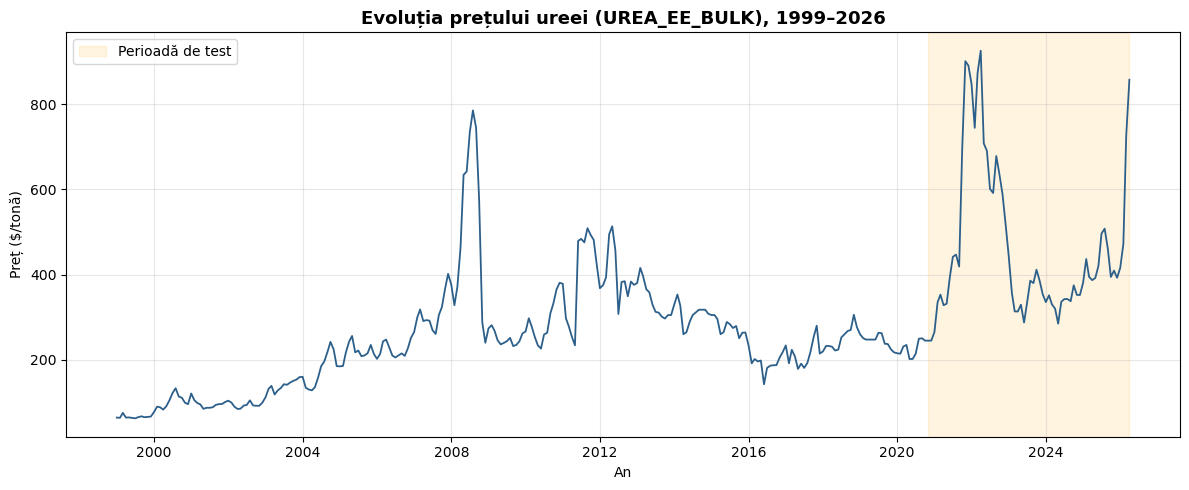

Salvat: figures/fig1_istoric_pret_uree.png


In [15]:
import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_prices_ext.index, df_prices_ext['UREA_EE_BULK'],
        color='#2c5f8a', linewidth=1.3)

# Evidentiem perioada de test (ultimele 20%)
test_start_date = df_prices_ext.index[int(len(df_prices_ext) * 0.8)]
ax.axvspan(test_start_date, df_prices_ext.index[-1],
           alpha=0.12, color='orange', label='Perioadă de test')

ax.set_title('Evoluția prețului ureei (UREA_EE_BULK), 1999–2026',
             fontsize=13, fontweight='bold')
ax.set_xlabel('An')
ax.set_ylabel('Preț ($/tonă)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/fig1_istoric_pret_uree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: figures/fig1_istoric_pret_uree.png")

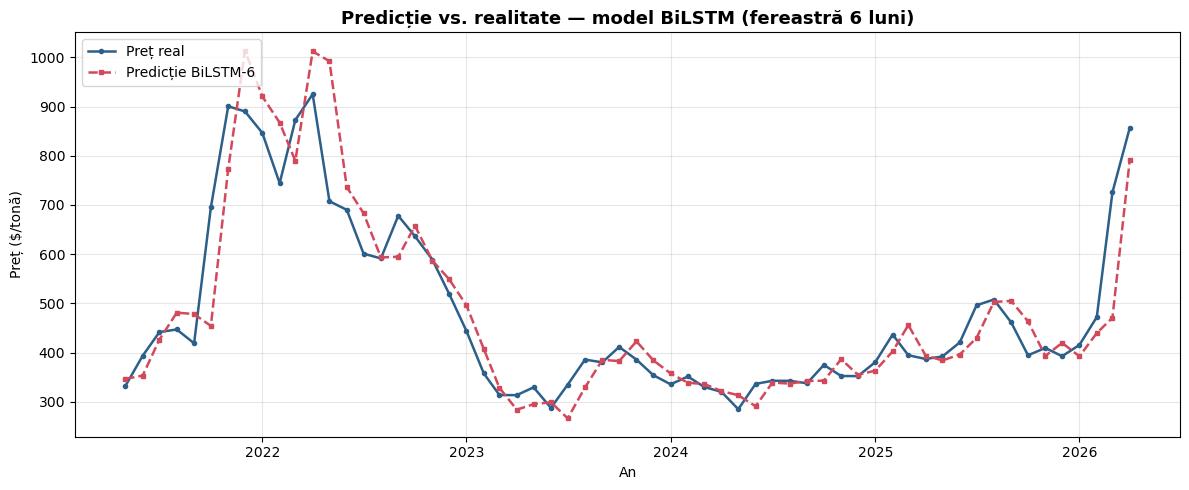

Salvat: figures/fig2_predictie_vs_real.png


In [16]:
# Regeneram predictiile modelului final pe test (BiLSTM-6)
final_model.eval()
with torch.no_grad():
    pred_scaled_f = final_model(torch.tensor(Xte_r, dtype=torch.float32)).numpy().flatten()

# Reconstruim preturile (aceeasi logica ca evaluate_model)
pred_price_f, true_price_f = evaluate_model(final_model, Xte_r, yte_r, scaler_r,
                                            df_prices_ext, train_size_r, LOOK_BACK_BEST)

# Datele calendaristice pentru axa X
test_dates = df_prices_ext.index[train_size_r + LOOK_BACK_BEST + 1 :
                                  train_size_r + LOOK_BACK_BEST + 1 + len(pred_price_f)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates, true_price_f, color='#2c5f8a', linewidth=1.8,
        label='Preț real', marker='o', markersize=3)
ax.plot(test_dates, pred_price_f, color='#d1495b', linewidth=1.8,
        label='Predicție BiLSTM-6', linestyle='--', marker='s', markersize=3)

ax.set_title('Predicție vs. realitate — model BiLSTM (fereastră 6 luni)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('An')
ax.set_ylabel('Preț ($/tonă)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/fig2_predictie_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: figures/fig2_predictie_vs_real.png")


  Early stopping la epoca 69


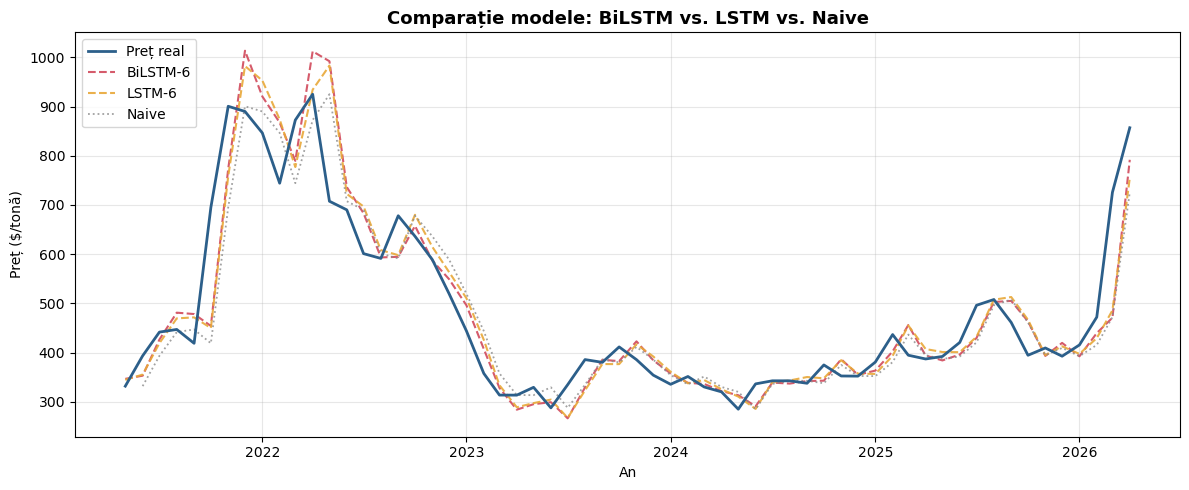

Salvat: figures/fig3_comparatie_modele.png


In [17]:
# Antrenam si LSTM-6 pentru comparatie vizuala (BiLSTM-6 il avem deja in final_model)
torch.manual_seed(42)
lstm6 = UreaLSTM(N_FEAT_EXT)
lstm6 = train_model(lstm6, X_t_r, y_t_r, X_v_r, y_v_r)
lstm6_pred, _ = evaluate_model(lstm6, Xte_r, yte_r, scaler_r, df_prices_ext, train_size_r, LOOK_BACK_BEST)

# Naive: pretul lunii anterioare
naive_pred_f = true_price_f[:-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates, true_price_f, color='#2c5f8a', linewidth=2, label='Preț real', zorder=3)
ax.plot(test_dates, pred_price_f, color='#d1495b', linewidth=1.5, linestyle='--', label='BiLSTM-6', alpha=0.9)
ax.plot(test_dates, lstm6_pred, color='#e8a838', linewidth=1.5, linestyle='--', label='LSTM-6', alpha=0.9)
ax.plot(test_dates[1:], naive_pred_f, color='#8a8a8a', linewidth=1.3, linestyle=':', label='Naive', alpha=0.8)

ax.set_title('Comparație modele: BiLSTM vs. LSTM vs. Naive', fontsize=13, fontweight='bold')
ax.set_xlabel('An')
ax.set_ylabel('Preț ($/tonă)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/fig3_comparatie_modele.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: figures/fig3_comparatie_modele.png")

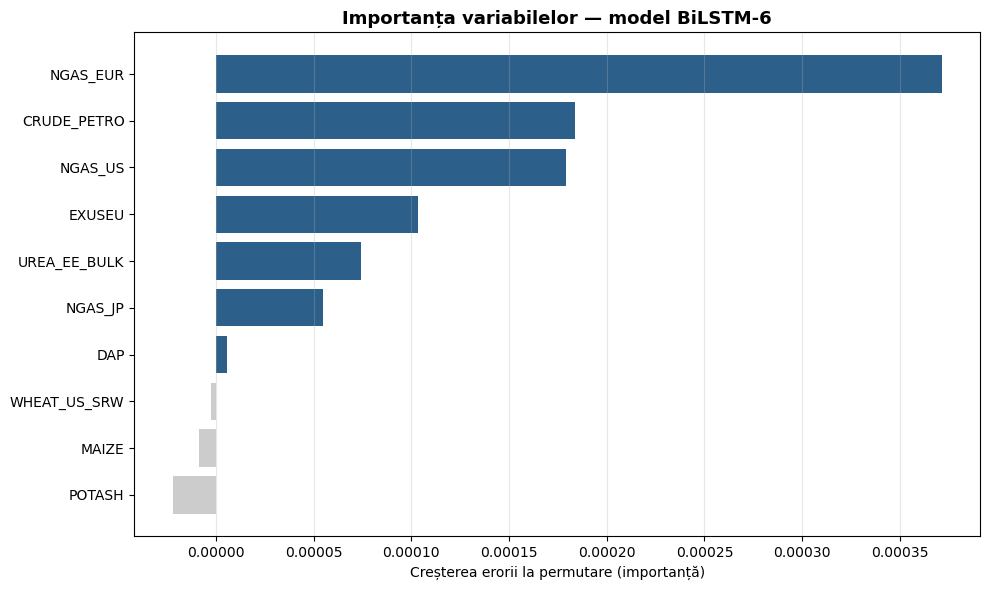

Salvat: figures/fig4_importanta_variabile.png

Clasament importanță:
  NGAS_EUR        0.00037
  CRUDE_PETRO     0.00018
  NGAS_US         0.00018
  EXUSEU          0.00010
  UREA_EE_BULK    0.00007
  NGAS_JP         0.00005
  DAP             0.00001
  WHEAT_US_SRW    -0.00000
  MAIZE           -0.00001
  POTASH          -0.00002


In [18]:
def permutation_importance(model, X_test, y_test, feature_names, n_repeats=10):
    model.eval()
    with torch.no_grad():
        base_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
    base_mse = np.mean((base_pred - y_test)**2)

    importances = []
    for feat_idx in range(X_test.shape[2]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            # Amestecam aleatoriu valorile acestei variabile pe toate ferestrele
            perm = np.random.permutation(X_perm.shape[0])
            X_perm[:, :, feat_idx] = X_perm[perm, :, feat_idx]
            with torch.no_grad():
                perm_pred = model(torch.tensor(X_perm, dtype=torch.float32)).numpy().flatten()
            perm_mse = np.mean((perm_pred - y_test)**2)
            scores.append(perm_mse - base_mse)  # cat de mult creste eroarea
        importances.append(np.mean(scores))
    return np.array(importances)

np.random.seed(42)
importances = permutation_importance(final_model, Xte_r, yte_r, features_ext)

# Sortam descrescator
order = np.argsort(importances)[::-1]
sorted_names = [features_ext[i] for i in order]
sorted_imp = importances[order]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2c5f8a' if imp > 0 else '#cccccc' for imp in sorted_imp]
ax.barh(range(len(sorted_names)), sorted_imp, color=colors)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()  # cea mai importanta sus
ax.set_xlabel('Creșterea erorii la permutare (importanță)')
ax.set_title('Importanța variabilelor — model BiLSTM-6', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()

plt.savefig('figures/fig4_importanta_variabile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvat: figures/fig4_importanta_variabile.png")
print("\nClasament importanță:")
for name, imp in zip(sorted_names, sorted_imp):
    print(f"  {name:15} {imp:.5f}")

In [19]:
# === MODEL REDUS: doar variabilele cu importanta pozitiva ===
features_red = ['UREA_EE_BULK', 'NGAS_EUR', 'CRUDE_PETRO', 'NGAS_US', 'EXUSEU', 'NGAS_JP']

# Reconstruim df cu doar aceste coloane
# Fisierul World Bank foloseste nume descriptive in antet (randul 4), nu coduri scurte
rename_map_red = {
    'Crude oil, average': 'CRUDE_PETRO',
    'Natural gas, US': 'NGAS_US',
    'Natural gas, Europe': 'NGAS_EUR',
    'Liquefied natural gas, Japan': 'NGAS_JP',
    'Maize': 'MAIZE',
    'Wheat, US SRW': 'WHEAT_US_SRW',
    'Urea': 'UREA_EE_BULK',
    'DAP': 'DAP',
    'Potassium chloride **': 'POTASH',
}
pink_cols_red = [c for c in features_red if c != 'EXUSEU']
df_pink_red = pd.read_excel('data/CMO-Historical-Data-Monthly.xlsx',
                            sheet_name='Monthly Prices', skiprows=4)
df_pink_red = df_pink_red.rename(columns={df_pink_red.columns[0]: 'Date'})
df_pink_red.columns = [str(c).strip() for c in df_pink_red.columns]
df_pink_red = df_pink_red.rename(columns=rename_map_red)
# Aruncam randul cu unitatile si pastram doar lunile valide 'YYYYMmm'
df_pink_red = df_pink_red[df_pink_red['Date'].astype(str).str.match(r'^\d{4}M\d{2}$')].copy()
df_pink_red['Date'] = pd.to_datetime(df_pink_red['Date'], format='%YM%m')
for col in pink_cols_red:
    df_pink_red[col] = pd.to_numeric(df_pink_red[col], errors='coerce')
df_pink_red = df_pink_red[['Date'] + pink_cols_red]

df_red = pd.merge(df_pink_red, df_fx, on='Date', how='inner')
df_red = df_red.sort_values('Date').set_index('Date').ffill()
df_red = df_red[features_red]

df_prices_red = df_red.copy()
df_logret_red = np.log(df_red / df_red.shift(1)).dropna()

N_FEAT_RED = len(features_red)
print(f"Model redus: {N_FEAT_RED} variabile -> {features_red}\n")

# === Verificare pe 5 seed-uri (BiLSTM-6, la fel ca modelul principal) ===
n = len(df_logret_red)
train_size_red = int(n * 0.8)
data_tr_red = df_logret_red.iloc[:train_size_red].values
data_te_red = df_logret_red.iloc[train_size_red:].values

scaler_red = MinMaxScaler(feature_range=(0, 1))
data_tr_red_s = scaler_red.fit_transform(data_tr_red)
data_te_red_s = scaler_red.transform(data_te_red)

Xtr_red, ytr_red = create_windows(data_tr_red_s, 6, 0)
Xte_red, yte_red = create_windows(data_te_red_s, 6, 0)

vs = int(len(Xtr_red) * 0.1)
X_t_red, y_t_red = Xtr_red[:-vs], ytr_red[:-vs]
X_v_red, y_v_red = Xtr_red[-vs:], ytr_red[-vs:]

seeds = [42, 7, 123, 2024, 99]
mapes_red, das_red = [], []

print("Verificare model REDUS (6 variabile), BiLSTM-6:\n")
print(f"{'Seed':>6} {'MAPE':>8} {'DirAcc':>8}")
print("-" * 26)
for s in seeds:
    torch.manual_seed(s)
    np.random.seed(s)
    m = UreaBiLSTM(N_FEAT_RED)
    m = train_model(m, X_t_red, y_t_red, X_v_red, y_v_red)
    pred, true = evaluate_model(m, Xte_red, yte_red, scaler_red, df_prices_red, train_size_red, 6)
    mae, rmse, mape, da = compute_metrics(true, pred)
    mapes_red.append(mape); das_red.append(da)
    print(f"{s:>6} {mape:>7.2f}% {da:>7.2f}%")

print("-" * 26)
print(f"{'Media':>6} {np.mean(mapes_red):>7.2f}% {np.mean(das_red):>7.2f}%")
print(f"{'Std':>6} {np.std(mapes_red):>7.2f}% {np.std(das_red):>7.2f}%")

print("\n=== COMPARATIE ===")
print(f"Model COMPLET (10 var): MAPE 9.17% | DirAcc 63.73%")
print(f"Model REDUS   (6 var):  MAPE {np.mean(mapes_red):.2f}% | DirAcc {np.mean(das_red):.2f}%")

Model redus: 6 variabile -> ['UREA_EE_BULK', 'NGAS_EUR', 'CRUDE_PETRO', 'NGAS_US', 'EXUSEU', 'NGAS_JP']

Verificare model REDUS (6 variabile), BiLSTM-6:

  Seed     MAPE   DirAcc
--------------------------
  Early stopping la epoca 78
    42    9.78%   57.63%
  Early stopping la epoca 94
     7    9.69%   61.02%
  Early stopping la epoca 73
   123    9.15%   59.32%
  Early stopping la epoca 88
  2024    9.22%   61.02%
  Early stopping la epoca 104
    99    9.42%   61.02%
--------------------------
 Media    9.45%   60.00%
   Std    0.25%    1.36%

=== COMPARATIE ===
Model COMPLET (10 var): MAPE 9.17% | DirAcc 63.73%
Model REDUS   (6 var):  MAPE 9.45% | DirAcc 60.00%


# Comparație cu modele clasice și căutarea arhitecturii optime

Această secțiune răspunde la trei întrebări cerute pentru evaluarea riguroasă a modelului:
1. **Modelele clasice (SARIMA/SARIMAX)** prezic prețul mai bine sau mai slab decât rețelele?
2. **Care arhitectură BiLSTM** este optimă pentru acest set (adâncime, lățime)?
3. Se **confirmă sau infirmă** că prețul poate fi estimat mai bine cu rețele neuronale?

Toate modelele sunt evaluate pe **exact aceeași perioadă de test**, prognoză la un pas (one-step-ahead).

## 1. Modele clasice: SARIMA și SARIMAX

SARIMA folosește doar istoricul prețului ureei; SARIMAX adaugă variabilele exogene (energie, îngrășăminte, curs), decalate cu o lună pentru a folosi doar informație din trecut.

In [ ]:
# ==========================================================================
# COMPARATIE CU MODELE CLASICE: SARIMA (univariat) si SARIMAX (cu exogene)
# ==========================================================================
# Comparam reteaua neuronala cu abordarea econometrica clasica, pe EXACT
# aceeasi perioada de test, one-step-ahead. Exogenele sunt decalate cu o luna
# (lag-1) ca modelul sa foloseasca doar informatie din trecut - la fel ca
# reteaua, care vede doar fereastra de luni anterioare (fara scurgere din viitor).
import warnings, itertools
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

prices_u = df_prices_ext['UREA_EE_BULK'].values
y_lr     = df_logret_ext['UREA_EE_BULK'].values
exog_cols = [c for c in features_ext if c != 'UREA_EE_BULK']
exog_all  = df_logret_ext[exog_cols].values
exog_lag  = np.vstack([np.zeros((1, exog_all.shape[1])), exog_all[:-1]])  # decalaj de o luna

# Aceeasi tinta de test ca evaluate_model (reconstructie identica)
test_start = train_size_r + LOOK_BACK_BEST + 1
n_test     = len(prices_u) - test_start
true_price_c = prices_u[test_start:test_start + n_test]
lr_start   = test_start - 1

def _score(pred_lr):
    prev = prices_u[test_start - 1: test_start - 1 + n_test]
    return compute_metrics(true_price_c, prev * np.exp(pred_lr))

def _pick_order(endog, exog=None):
    """Alege ordinul (p,0,q) dupa AIC; d=0 fiindca log-returns sunt stationare."""
    best = (None, np.inf)
    for p, q in itertools.product([0, 1, 2], [0, 1, 2]):
        try:
            r = SARIMAX(endog, exog=exog, order=(p, 0, q),
                        enforce_stationarity=False, enforce_invertibility=False
                        ).fit(disp=False, maxiter=200)
            if r.aic < best[1]:
                best = ((p, 0, q), r.aic)
        except Exception:
            pass
    return best[0]

def _walk_forward(order, use_exog):
    """Antreneaza pe train, apoi prognozeaza o luna inainte extinzand cu valorile reale."""
    ex = exog_lag if use_exog else None
    res = SARIMAX(y_lr[:lr_start], exog=(ex[:lr_start] if use_exog else None), order=order,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, maxiter=300)
    preds = []
    for k in range(n_test):
        pos = lr_start + k
        ex_now = ex[pos:pos + 1] if use_exog else None
        preds.append(float(res.forecast(steps=1, exog=ex_now)[0]))
        res = res.append(y_lr[pos:pos + 1], exog=ex_now, refit=False)
    return np.array(preds)

ord_sarima  = _pick_order(y_lr[:lr_start]);                          print('Ordin SARIMA :', ord_sarima)
ord_sarimax = _pick_order(y_lr[:lr_start], exog=exog_lag[:lr_start]); print('Ordin SARIMAX:', ord_sarimax)

_, _, mape_sarima,  da_sarima  = _score(_walk_forward(ord_sarima,  False))
_, _, mape_sarimax, da_sarimax = _score(_walk_forward(ord_sarimax, True))

# Naiv (random walk): pretul de luna trecuta = predictia (log-return prezis = 0)
_, _, mape_naiv, da_naiv = _score(np.zeros(n_test))

print(f"\n{'Model':<22}{'MAPE':>10}{'DirAcc':>12}")
print('-' * 44)
print(f"{'Naiv':<22}{mape_naiv:>8.2f}%{da_naiv:>10.2f}%")
print(f"{'SARIMA':<22}{mape_sarima:>8.2f}%{da_sarima:>10.2f}%")
print(f"{'SARIMAX (+exogene)':<22}{mape_sarimax:>8.2f}%{da_sarimax:>10.2f}%")


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Ordin SARIMA : (2, 0, 1)
Ordin SARIMAX: (1, 0, 2)

Model                       MAPE      DirAcc
--------------------------------------------
Naiv                      9.73%     54.24%
SARIMA                    9.69%     64.41%
SARIMAX (+exogene)        8.58%     61.02%


## 2. Ablation: căutarea arhitecturii optime BiLSTM

Comparăm modelul final (1 strat, 32 unități) cu variante mai adânci (2 și 3 straturi) și mai late (64 unități), plus un LSTM unidirecțional. Toate pe aceleași 5 seed-uri.

In [22]:
# ==========================================================================
# CAUTAREA ARHITECTURII OPTIME — ablation (adancime, latime, uni- vs. bidirectional)
# ==========================================================================
# Antrenam mai multe arhitecturi pe ACELASI split si aceleasi 5 seed-uri,
# ca sa vedem daca o retea mai adanca/lata aduce imbunatatiri sau doar
# suprainvata setul mic. Astfel justificam alegerea arhitecturii finale.

class UreaRNN(nn.Module):
    """LSTM/BiLSTM parametrizabil: numar de straturi, dimensiune, directie."""
    def __init__(self, input_size, hidden_size=32, num_layers=1,
                 dropout=0.0, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if num_layers > 1 else 0.0)
        mult = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * mult, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

seeds = [42, 7, 123, 2024, 99]
arhitecturi = [
    ('Naiv (random walk)',            None),
    ('SARIMA',                        None),
    ('SARIMAX (+exogene)',            None),
    ('LSTM-6 (unidirectional)',       dict(hidden_size=32, num_layers=1, bidirectional=False)),
    ('BiLSTM-6, 1 strat, h=32 (final)', dict(hidden_size=32, num_layers=1)),
    ('BiLSTM-6, 2 straturi, h=32',    dict(hidden_size=32, num_layers=2, dropout=0.2)),
    ('BiLSTM-6, 3 straturi, h=32',    dict(hidden_size=32, num_layers=3, dropout=0.2)),
    ('BiLSTM-6, 1 strat, h=64',       dict(hidden_size=64, num_layers=1)),
]

rezultate = {}
print(f"{'Model':<34}{'MAPE (medie±std)':>20}{'DirAcc (medie±std)':>22}")
print('-' * 76)
# clasicele (rezultate deja calculate mai sus)
for nume, mape, da in [('Naiv (random walk)', mape_naiv, da_naiv),
                       ('SARIMA', mape_sarima, da_sarima),
                       ('SARIMAX (+exogene)', mape_sarimax, da_sarimax)]:
    rezultate[nume] = (mape, 0.0, da, 0.0)
    print(f"{nume:<34}{mape:>13.2f}%{da:>18.2f}%")
# retelele neuronale (5 seed-uri fiecare)
for nume, kw in arhitecturi:
    if kw is None:
        continue
    mapes, das = [], []
    for s in seeds:
        torch.manual_seed(s); np.random.seed(s)
        m = UreaRNN(N_FEAT_EXT, **kw)
        m = train_model(m, X_t_r, y_t_r, X_v_r, y_v_r)
        pred, true = evaluate_model(m, Xte_r, yte_r, scaler_r, df_prices_ext,
                                    train_size_r, LOOK_BACK_BEST)
        _, _, mape, da = compute_metrics(true, pred)
        mapes.append(mape); das.append(da)
    rezultate[nume] = (np.mean(mapes), np.std(mapes), np.mean(das), np.std(das))
    print(f"{nume:<34}{np.mean(mapes):>8.2f}% ±{np.std(mapes):<4.2f}{np.mean(das):>11.2f}% ±{np.std(das):<4.2f}")


Model                                 MAPE (medie±std)    DirAcc (medie±std)
----------------------------------------------------------------------------
Naiv (random walk)                         9.73%             54.24%
SARIMA                                     9.69%             64.41%
SARIMAX (+exogene)                         8.58%             61.02%
  Early stopping la epoca 69
  Early stopping la epoca 71
  Early stopping la epoca 88
  Early stopping la epoca 63
  Early stopping la epoca 69
LSTM-6 (unidirectional)               9.49% ±0.17      59.32% ±2.63
  Early stopping la epoca 66
  Early stopping la epoca 74
  Early stopping la epoca 62
  Early stopping la epoca 72
  Early stopping la epoca 77
BiLSTM-6, 1 strat, h=32 (final)       9.17% ±0.18      63.73% ±2.96
  Early stopping la epoca 50
  Early stopping la epoca 557
  Early stopping la epoca 68
  Early stopping la epoca 88
BiLSTM-6, 2 straturi, h=32            9.31% ±0.23      59.66% ±2.49
  Early stopping la epoca 49
  

## 3. Tabel comparativ consolidat și figură

                          Model  MAPE (%)  Acuratete directionala (%)
             Naiv (random walk)      9.73                       54.24
                         SARIMA      9.69                       64.41
             SARIMAX (+exogene)      8.58                       61.02
        LSTM-6 (unidirectional)      9.49                       59.32
BiLSTM-6, 1 strat, h=32 (final)      9.17                       63.73
     BiLSTM-6, 2 straturi, h=32      9.31                       59.66
     BiLSTM-6, 3 straturi, h=32      9.66                       57.63
        BiLSTM-6, 1 strat, h=64      9.47                       60.00


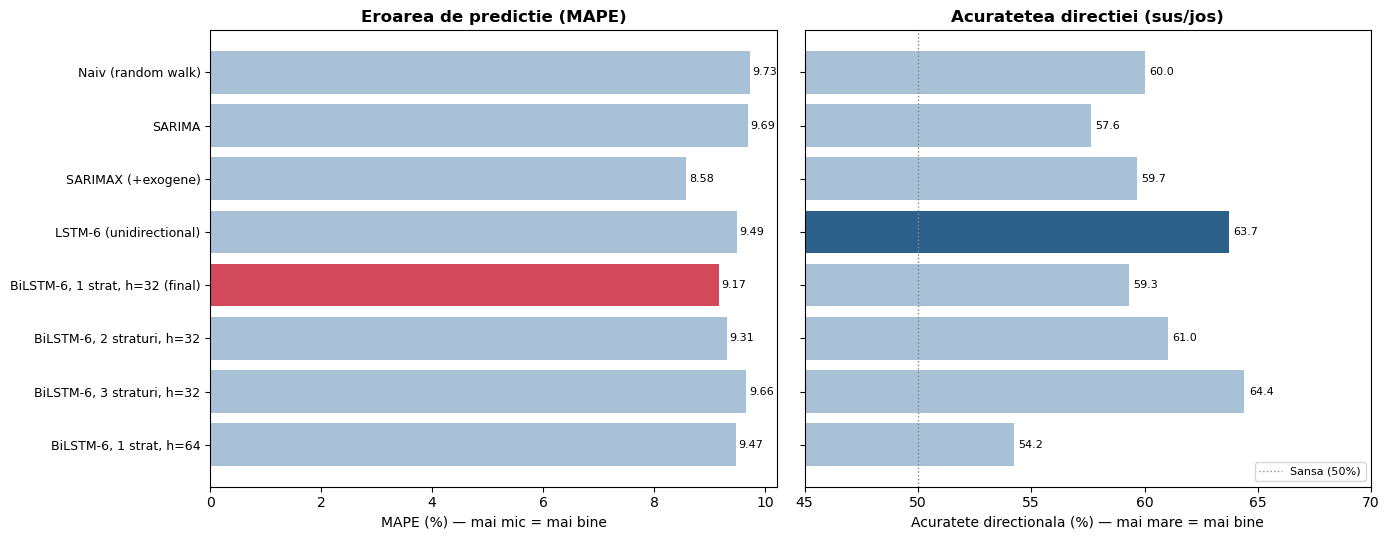


Salvat: figures/fig5_comparatie_modele_clasice_vs_retele.png


In [23]:
# ==========================================================================
# TABEL COMPARATIV CONSOLIDAT + FIGURA PENTRU TEZA
# ==========================================================================
import os
os.makedirs('figures', exist_ok=True)

ordine = ['Naiv (random walk)', 'SARIMA', 'SARIMAX (+exogene)',
          'LSTM-6 (unidirectional)', 'BiLSTM-6, 1 strat, h=32 (final)',
          'BiLSTM-6, 2 straturi, h=32', 'BiLSTM-6, 3 straturi, h=32',
          'BiLSTM-6, 1 strat, h=64']

tabel = pd.DataFrame(
    [(n, rezultate[n][0], rezultate[n][2]) for n in ordine if n in rezultate],
    columns=['Model', 'MAPE (%)', 'Acuratete directionala (%)']
).round(2)
print(tabel.to_string(index=False))

# --- Figura: doua bare orizontale (MAPE mai mic = mai bine, DirAcc mai mare = mai bine) ---
mods = tabel['Model'].tolist()
mape_v = tabel['MAPE (%)'].values
da_v   = tabel['Acuratete directionala (%)'].values
best_idx = 'BiLSTM-6, 1 strat, h=32 (final)'
cols_mape = ['#d1495b' if m == best_idx else '#a9c1d6' for m in mods]
cols_da   = ['#2c5f8a' if m == best_idx else '#a9c1d6' for m in mods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
yp = np.arange(len(mods))

ax1.barh(yp, mape_v, color=cols_mape)
ax1.set_yticks(yp); ax1.set_yticklabels(mods, fontsize=9)
ax1.invert_yaxis(); ax1.set_xlabel('MAPE (%) — mai mic = mai bine')
ax1.set_title('Eroarea de predictie (MAPE)', fontweight='bold')
for i, v in enumerate(mape_v):
    ax1.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=8)

ax2.barh(yp, da_v, color=cols_da)
ax2.set_yticks(yp); ax2.set_yticklabels([])
ax2.axvline(50, color='#888', linestyle=':', linewidth=1, label='Sansa (50%)')
ax2.set_xlabel('Acuratete directionala (%) — mai mare = mai bine')
ax2.set_title('Acuratetea directiei (sus/jos)', fontweight='bold')
ax2.set_xlim(45, 70); ax2.legend(loc='lower right', fontsize=8)
for i, v in enumerate(da_v):
    ax2.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig5_comparatie_modele_clasice_vs_retele.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSalvat: figures/fig5_comparatie_modele_clasice_vs_retele.png')


In [24]:
import pandas_datareader.data as web
import datetime

# Luam cursul USD/EUR de la FRED (seria EXUSEU) din 1999 pana azi
start = datetime.datetime(1999, 1, 1)
end = datetime.datetime.now()

df_fred = web.DataReader('EXUSEU', 'fred', start, end)
print(f"Descarcat: {df_fred.shape[0]} randuri")
print(f"Interval: {df_fred.index.min()} -> {df_fred.index.max()}")
print(f"\nUltimele 5 valori:")
print(df_fred.tail())

Descarcat: 330 randuri
Interval: 1999-01-01 00:00:00 -> 2026-06-01 00:00:00

Ultimele 5 valori:
            EXUSEU
DATE              
2026-02-01  1.1824
2026-03-01  1.1557
2026-04-01  1.1697
2026-05-01  1.1681
2026-06-01  1.1516
